# Combat DPS curves

Per-role DPS at level N for the seeded roster. Quick sanity check that
leveling actually scales output â€” and a heatmap of which seeded heroes
are over- or under-tuned for their tier.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import os
os.environ.setdefault('HEROPROTO_ENVIRONMENT', 'dev')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from app.combat import scale_stat, power_rating
from app.seed import HERO_SEEDS

In [2]:
# Build a frame of every seeded hero with their stats at level 1, 10, 20, 30.
rows = []
for h in HERO_SEEDS:
    for lvl in (1, 10, 20, 30):
        hp = scale_stat(h['base_hp'], lvl)
        atk = scale_stat(h['base_atk'], lvl)
        df = scale_stat(h['base_def'], lvl)
        spd = h['base_spd']
        rows.append({
            'name': h['name'], 'rarity': str(h['rarity']), 'role': str(h['role']),
            'level': lvl, 'hp': hp, 'atk': atk, 'def': df, 'spd': spd,
            'power': power_rating(hp, atk, df, spd),
            'dps_proxy': atk * spd / 100,  # crude single-target DPS proxy
        })
df = pd.DataFrame(rows)
df.head()

,name,rarity,role,level,hp,atk,def,spd,power,dps_proxy
0,Ticket Gremlin,COMMON,ATK,1,800,90,60,95,528,85.50
1,Ticket Gremlin,COMMON,ATK,10,1520,171,114,95,832,162.45
2,Ticket Gremlin,COMMON,ATK,20,2320,261,174,95,1170,247.95
3,Ticket Gremlin,COMMON,ATK,30,3120,351,234,95,1508,333.45
4,Printer Whisperer,COMMON,SUP,1,900,70,70,90,531,63.00


C:\Users\User\AppData\Local\Temp\ipykernel_8032\3128067482.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lvl30['name'], rotation=70, ha='right', fontsize=8)


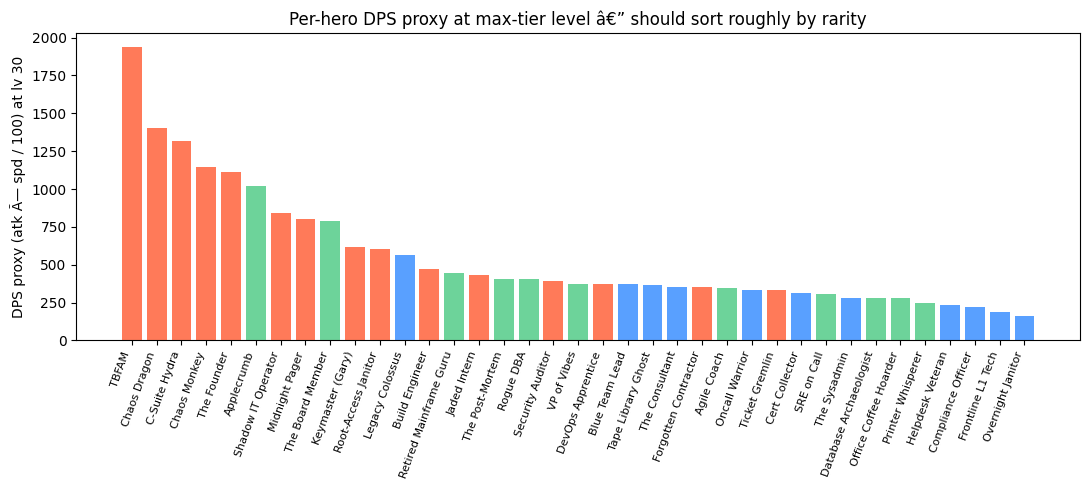

In [3]:
# DPS-proxy curve by role at level 30.
fig, ax = plt.subplots(figsize=(11, 5))
lvl30 = df[df.level == 30].sort_values('dps_proxy', ascending=False)
color_map = {'ATK': '#ff7a59', 'DEF': '#59a0ff', 'SUP': '#6dd39a'}
ax.bar(lvl30['name'], lvl30['dps_proxy'], color=[color_map.get(r, '#888') for r in lvl30['role']])
ax.set_xticklabels(lvl30['name'], rotation=70, ha='right', fontsize=8)
ax.set_ylabel('DPS proxy (atk Ã— spd / 100) at lv 30')
ax.set_title('Per-hero DPS proxy at max-tier level â€” should sort roughly by rarity')
fig.tight_layout()
fig.savefig('output/combat_dps_proxy_lv30.png', dpi=120, facecolor='white')
plt.show()